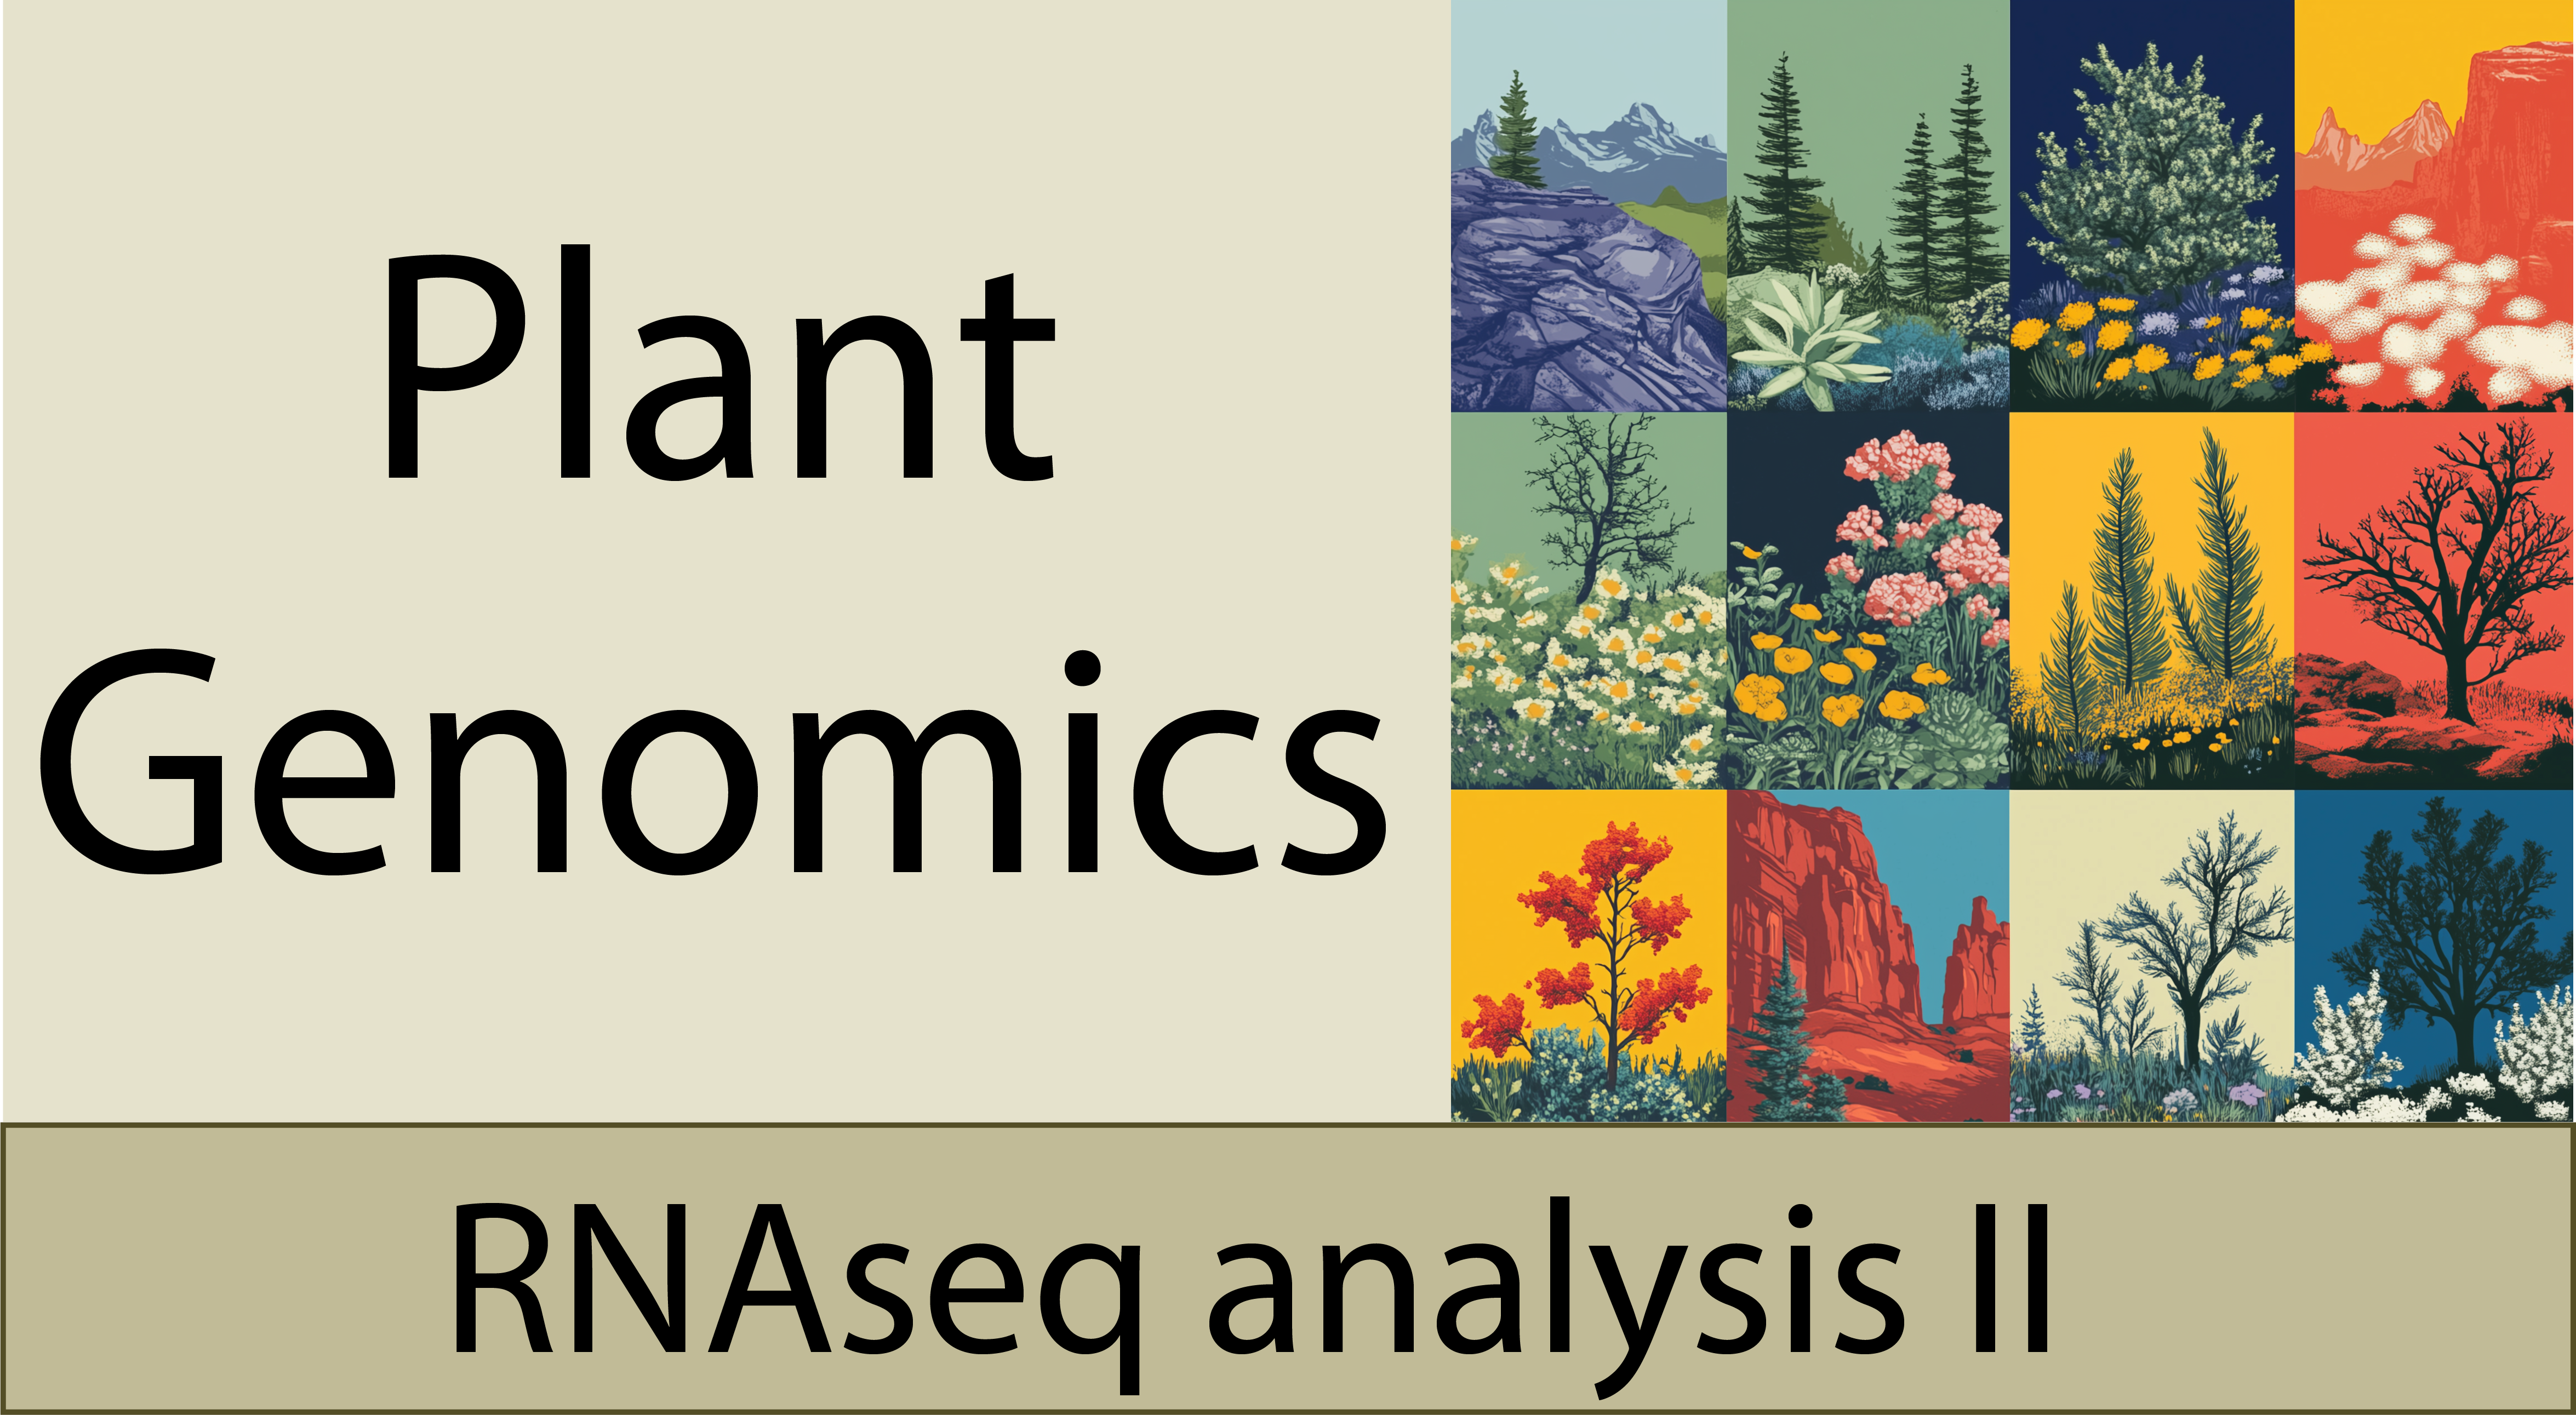

In the last lesson, we learned how to trim and pseudo/quasi-align RNAseq reads against a set of transcripts, but this is just the beginning. There are many downstream analyses we can do with RNAseq, including:

**Differential Expression Analysis (DE):**
This is one of the most common applications of RNAseq. By comparing gene expression levels between different conditions (e.g., treated vs. untreated, or different tissues), we can identify genes that are differentially expressed. Tools such as DESeq2 or edgeR can help us statistically determine which genes show significant differences in expression levels. These genes often provide insights into the biological processes or pathways affected by a particular condition.

**Co-expression Network Analysis:**
RNAseq data can be used to explore gene co-expression networks, where genes that have similar expression patterns across multiple samples or conditions are grouped together. This can help identify modules of genes that may be co-regulated or function in the same biological pathway. Tools like WGCNA (Weighted Gene Co-expression Network Analysis) are often used for this type of analysis.

**Integration with Other Omics Data:**
RNAseq data can be integrated with other types of biological data to gain deeper insights into cellular processes. For instance, combining RNAseq with proteomics (protein abundance data) can reveal the extent to which mRNA expression correlates with protein levels. Other data types, like metabolomics or epigenomics (e.g., DNA methylation or histone modifications), can also be integrated to understand the regulatory mechanisms controlling gene expression.

**Functional Enrichment Analysis:**
After identifying differentially expressed genes or co-expressed gene clusters, we can perform functional enrichment analysis to determine whether particular biological pathways, gene ontology (GO) terms, or molecular functions are overrepresented. This helps in interpreting the biological significance of gene expression changes.

**Predictive Modeling:**
RNAseq data can be used to develop predictive models that link gene expression patterns to specific phenotypes or outcomes. This approach involves training machine learning models on gene expression data to predict a target variable, such as disease status, treatment response, or developmental stage. Common algorithms include decision trees, random forests, support vector machines (SVM), and neural networks, depending on the complexity and nature of the data.

**Splicing Analysis and Isoform Usage:**
RNAseq data can also be used to study alternative splicing events, where different exons of a gene are included or excluded from the final mRNA transcript. This can lead to different protein isoforms being produced from the same gene, which may have different functions or regulatory roles. Tools like rMATS or SUPPA2 can help identify and quantify alternative splicing events.

**Comparative Transcriptomics:**
This involves comparing transcriptomes (the complete set of RNA transcripts) between different species, strains, or individuals to study evolutionary conservation or divergence in gene expression patterns. This can help identify orthologous genes and understand how gene regulation evolves.

**Single-Cell RNAseq Analysis:**
RNAseq can also be applied to single cells, providing high-resolution insights into cell-specific gene expression profiles. This is especially useful for studying heterogeneous tissues or identifying rare cell populations within a tissue.

Each of these analyses can provide unique insights into gene regulation, biological processes, and cellular responses to different stimuli or conditions, making RNAseq a powerful tool in genomics and functional biology research. We could spend a whole semester exploring all of the downstream analyses of RNAseq, but in this lesson we will do some simple quality control and analyze some enriched gene ontology terms output from differential expression analysis. 


## Principal Component Analysis
Principal Component Analysis (PCA) is a valuable tool for quality control in RNAseq experiments, providing an intuitive way to visualize and assess how well biological replicates cluster together and how different experimental conditions, such as tissues or treatments, separate from each other. RNAseq experiments often generate expression data for tens of thousands of genes across multiple samples, which can be overwhelming to interpret manually. PCA reduces the dimensionality of the data, condensing this complex information into a small number of principal components that capture the most significant variation. By plotting the samples in this reduced space, we can quickly identify patterns, outliers, or inconsistencies in the data.

When RNAseq data is plotted in two dimensions using the first two principal components, replicates of the same condition (e.g., samples from the same tissue or treatment) should cluster closely together. This indicates that the technical or biological replicates are consistent with each other, which is a good indicator of data quality. On the other hand, if replicates from the same condition do not cluster together, this might indicate technical issues, such as batch effects, sequencing errors, or sample mislabeling, which need to be addressed before moving forward with downstream analysis.

A PCA or other forms of dimensionality reduction can also help us to compare how different conditions, such as tissues, treatments, or time points, separate in the principal component space. For example, samples from distinct tissues (e.g., root vs. leaf) should ideally separate from each other along the first or second principal components, reflecting the expected biological differences between them. If tissue types do not show distinct separation, it might suggest a problem with the experiment, such as contamination between samples or insufficient RNA extraction. This visual inspection gives an early indication of how well the RNAseq data captures biological variability and ensures that any differences observed are due to genuine biological differences rather than technical noise. I have provided a matrix of gene expression data and we will use python to import, transform, and plot the gene expression data. 
If you want to learn more about dimensionality reduction and PCA and how to run a PCA using python in more detail, I have created a youtube video!

https://www.youtube.com/watch?v=Rq4ZoDutfqU&t=1563s&ab_channel=bobvanburen


**Note:** Python is not a prerequisite for this course, and I have provided all of the code you need here, along with some explanation of what each line is doing.ssion analysis. 


We must first install Python libraries in our Jupyter notebook environment, including the scikit-learn library, which is used for machine learning algorithms, and includes simpler tools like PCA, the matplotlib library, a popular library for creating visualizations and plots, and the seaborn library, which builds on matplotlib and provides additional functionalities for statistical data visualization. 

**Note:** after running these three cells, you will probably need to restart your kernel. 

In [ ]:
%pip install scikit-learn

In [ ]:
%pip install matplotlib

In [ ]:
%pip install seaborn

Import statements will load various Python libraries (pandas, numpy, scikit-learn, matplotlib, and seaborn) into the environment, enabling their functions for data manipulation, numerical operations, dimensionality reduction, and data visualization. You will know everything is installed correctly if this code does not throw any errors. 

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

Now, let's load some data. I have provided some gene expression data from teff, and we can load this into Python as a pandas DataFrame. A pandas DataFrame is a powerful data structure that organizes data in a table format, similar to an Excel spreadsheet, with labeled rows and columns. This allows us to easily manipulate, filter, and analyze the data, making it an essential tool for working with structured datasets. 

**Note:** you will need to make sure the tef_expression.txt file is in the same directory as your jupyter notebook. You could also provide the full path of the file as well. 

In [2]:
# Load the data
file_path = 'tef_expression.txt'  # Replace with the path to your file
df = pd.read_csv(file_path, sep='\t')

# Set Gene_ID as the index
df.set_index('Gene_ID', inplace=True)
df

,M1_seed_R1,M1_seed_R2,M1_seed_R3,M2_seed_R1,M2_seed_R2,M2_seed_R3,Leaf_R1,Leaf_R2,Leaf_R3,Internode_R1,...,Root_R3,Seedling_root_R1,Seedling_root_R2,Seedling_root_R3,Seedling_shoot_R1,Seedling_shoot_R2,Seedling_shoot_R3,Leaf_drought_R1,Leaf_drought_R2,Leaf_drought_R3
Gene_ID,,,,,,,,,,,,,,,,,,,,,
Et_1A_005362_Et_Un_067514,437.490463,390.069806,482.929434,460.658347,294.813733,1102.322170,536.061082,476.459196,737.337357,318.758587,...,251.276943,366.634023,342.224529,279.739276,379.135537,392.234518,359.190124,340.910330,604.088544,1049.854609
Et_1A_005363_Et_Un_067521,38.819070,47.975194,86.539536,56.274102,38.821990,100.188915,86.650052,78.437334,92.341553,55.772958,...,67.340367,9.622858,45.488519,31.104486,157.015047,135.737775,191.634394,276.874058,237.531075,516.873087
Et_1A_005358_Et_Un_067518,23.903977,17.551828,47.075660,21.166322,20.158580,58.435345,2.999328,0.999514,0.960335,9.512745,...,28.474814,53.521114,107.326324,59.013507,45.425895,43.005894,76.323273,0.000000,0.000000,0.000000
Et_1A_005364_Et_Un_067520,16.035041,65.453597,158.341059,115.392086,7.406192,59.320112,0.970219,2.978374,2.888564,24.602182,...,5.561605,3.593790,26.205110,12.084610,58.050201,70.978386,63.576770,6.468440,2.958588,6.059157
Et_1A_005360_Et_Un_067516,375.898883,575.577191,622.265206,842.204448,148.923493,540.147349,364.468055,299.525491,695.661527,73.750009,...,0.000000,6.837706,11.598918,17.514751,1813.148839,1967.108314,1579.727213,27.872893,61.503745,113.573922
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Et_10A_002141_Et_10B_003492,26.504349,10.217929,19.337947,33.616728,11.309495,71.372207,30.503670,21.420002,28.600952,24.111975,...,16.372502,8.147109,21.768129,18.166068,22.525058,28.914537,34.772046,32.632784,22.882641,31.782726
Et_10A_001366_Et_10B_003491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Et_10A_001359_Et_10B_003487,77.414665,203.412869,233.452814,296.569263,57.757883,202.929806,11.336829,10.129556,2.295034,84.596179,...,43.555625,155.900771,110.934627,52.609932,107.285899,98.470943,107.503690,0.000000,23.887585,4.912889


This DataFrame structure represents gene expression data, where:

Rows correspond to genes, with each row identified by a unique Gene_ID (e.g., Et_1A_005362_Et_Un_067514).

Columns represent different experimental conditions or biological replicates, such as tissue types and replicates (e.g., M1_seed_R1, Leaf_R2, Root_R3, etc.). Each column contains expression values (e.g., Transcripts Per Million, or TPM) for that gene under a specific condition.

Cells contain the numerical gene expression values, representing how much a particular gene is expressed under the corresponding condition.
This structure is ideal for organizing RNAseq data, allowing easy access and manipulation of gene expression values across multiple tissues or experimental replicates for analysis.

We log2 transform expression data prior to PCA to stabilize the variance and reduce the influence of extremely high expression values. RNAseq data often has a wide dynamic range, with some genes having very high expression and others very low. This skewed distribution can dominate the variance and distort the analysis. Log2 transformation compresses the range of expression values, making the data more normally distributed, which improves the performance of PCA and helps it focus on meaningful biological variation rather than being dominated by a few highly expressed genes.

This code blow performs a PCA (Principal Component Analysis) on RNAseq gene expression data (our dataframe, or df) to visualize how different samples (e.g., tissues) relate to each other based on their gene expression profiles. First, it log2 transforms the expression data (df_log2 = np.log2(df + 1)) to stabilize variance and reduce the influence of highly expressed genes. After this, any rows (genes) with missing values are dropped, and the cleaned data is transposed so that samples are the rows, and genes are the columns. The PCA is then performed to reduce the dimensionality of the dataset to two principal components (PC1 and PC2), capturing the most significant variation between the samples.

The code then creates a DataFrame to store the PCA results, adds a "Tissue" column by extracting the tissue type from the sample names, and generates a scatterplot using seaborn. This scatterplot visualizes the samples in the reduced PCA space, with each point representing a sample, and colors indicating different tissues. This plot helps assess the similarity between replicates (which should cluster together) and the separation between different tissues or conditions.

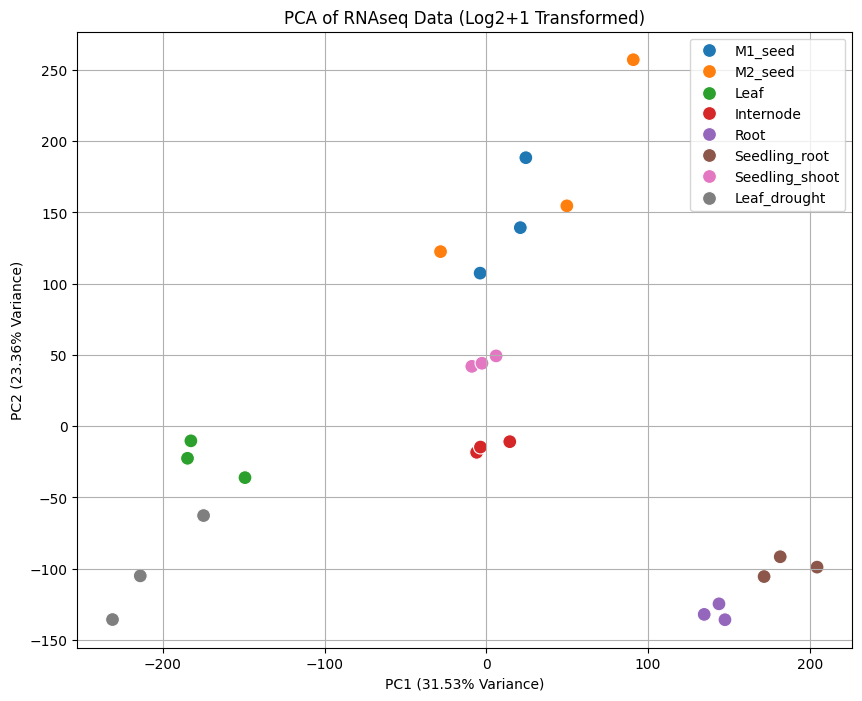

In [3]:
# Log2+1 transformation
df_log2 = np.log2(df + 1)

# Drop any rows with missing values (genes with missing data)
df_log2_clean = df_log2.dropna()

# Transpose the cleaned dataframe
df_log2_T = df_log2_clean.T

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_log2_T)

# Calculate the percentage of variance explained by PC1 and PC2
explained_variance = pca.explained_variance_ratio_ * 100

# Create a dataframe for PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'], index=df_log2_T.index)

# Add tissue type based on sample name
pca_df['Tissue'] = pca_df.index.str.replace(r'_R\d+', '', regex=True)

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Tissue', palette='tab10', s=100)

# Add plot labels with variance explained
plt.title('PCA of RNAseq Data (Log2+1 Transformed)')
plt.xlabel(f'PC1 ({explained_variance[0]:.2f}% Variance)')
plt.ylabel(f'PC2 ({explained_variance[1]:.2f}% Variance)')
plt.legend(loc='best')
plt.grid(True)

# Show the plot
plt.show()

### Questions
1. How do the three RNAseq replicates compare to each other based on the PCA. Is there a lot of variance? Do you think this is good data? 

2. Do the samples group as expected based on their biological context? For example, are similar tissue types positioned near each other in the PCA plot? Does this separation align with what you would anticipate biologically?

3. Which pairwise comparison of the samples would be the most biologically interesting? Based on the PCA results, which comparison between tissue samples or groups appears to exhibit the most meaningful or intriguing differences that might be worth exploring further?

Answers:
1.
2.
3.

## Differential gene expression analysis

Differential Gene Expression (DGE) Analysis is a key technique used in RNAseq data analysis to identify genes that show statistically significant changes in expression between different experimental conditions. For example, you may want to compare gene expression in control and drought stressed plants to identify candidates for further study that are upregulated  in response to water deficit. This analysis typically begins by normalizing raw RNAseq counts (to account for sequencing depth or library size) and then applying statistical models to identify genes with significant expression differences. Popular tools like DESeq2, edgeR, and limma use statistical methods such as negative binomial distribution to estimate the likelihood that observed differences are due to biological variation rather than random noise. The results of DGE analysis are typically presented as a list of significantly differentially expressed genes, often accompanied by measures like log-fold change and p-values or adjusted p-values to control for false discoveries.

Once a set of differentially expressed genes (DEGs) has been identified, we often perform Gene Ontology (GO) Enrichment Analysis to interpret the biological significance of these changes. GO terms provide a structured vocabulary to describe gene functions, biological processes, and cellular components. GO enrichment analysis helps identify whether certain biological processes or functions are overrepresented among the DEGs compared to the background (typically all genes in the genome or all genes in the experiment). For example, if many of the upregulated genes in a drought-stressed plant are associated with the GO term "response to water deprivation," it would suggest that the plant is activating stress-response pathways to cope with drought.

The enrichment analysis is done by comparing the frequency of specific GO terms among the DEGs to the expected frequency in the background set. Statistical tests, such as Fisher’s exact test or hypergeometric distribution, are used to determine whether the overrepresentation of a GO term is significant. The output of GO enrichment analysis typically includes a list of GO terms along with p-values indicating the significance of enrichment. This helps to contextualize the gene expression changes in terms of broader biological processes, providing a more comprehensive understanding of the molecular mechanisms underlying the experimental conditions. Overall, combining DGE analysis with GO enrichment enables us to move from identifying individual genes to understanding the biological pathways and systems involved in the response to the experimental condition.


### Gene Ontology enrichment
Let’s perform a gene ontology (GO) enrichment analysis on two sets of upregulated genes identified from treatment vs. control comparisons in Arabidopsis thaliana. Your goal will be to run the GO term enrichment analysis and, based on the results, hypothesize what type of stress or tissue comparison the data might represent. The two gene sets, named "Arabidopsis_upregulated_gene_list1" and "Arabidopsis_upregulated_gene_list2," are available on GitHub and come from two distinct experimental conditions.

There are several ways to perform GO enrichment, including both command-line tools and online platforms. For command-line tools, popular options include GOseq, topGO, and GOAtools For web-based analyses, Phytozome and other genome hubs have built in tools and are user-friendly.

When running GO enrichment via command line, you typically need three key inputs:
1.	GO term annotations for each gene, which are often available in GO databases or annotation files for your organism (in this case, Arabidopsis).
2.	A background set of genes, which usually includes either all genes in the genome or all genes with detectable expression in your dataset.
3.	Your gene set(s) of interest, which in this case are the upregulated genes from the two comparisons.

Once the analysis is completed, you will be provided with enriched GO terms that represent biological processes, molecular functions, or cellular components that are overrepresented in your gene sets. This information will help you interpret the biological significance of the upregulated genes and allow you to infer possible experimental conditions based on the enrichment results. For this exercise, we can run GO term enrichment on Arabidopsis.org by simply pasting in the two sets of enriched genes separately, and interpreting the outputs: 


https://v2.arabidopsis.org/tools/go_term_enrichment.jsp

### Questions:

1.	What are the most significantly enriched GO terms for set 1?
2.	What do you think this experiment/tissue comparison was from? 
3.	What are the most significantly enriched GO terms for set 2?
4.	What do you think this experiment/tissue comparison was from? 

Answers:
1. 
2.
3.
4.